In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


## Data Preprocessing
In this step, we handle missing values, remove unnecessary columns, and prepare the dataset for analysis.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## Data Preprocessing
In this step, we handle missing values, remove unnecessary columns, and prepare the dataset for analysis.

In [3]:
# Check missing values
df.isnull().sum()

# Drop unnecessary columns (example)
df = df.drop(['Education','Income'], axis=1, errors='ignore')

# Convert data types if needed

## Exploratory Data Analysis (EDA)
We analyze the dataset to understand patterns and relationships between features.

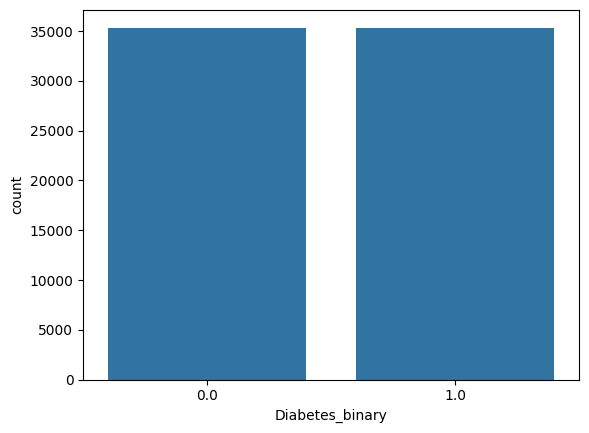

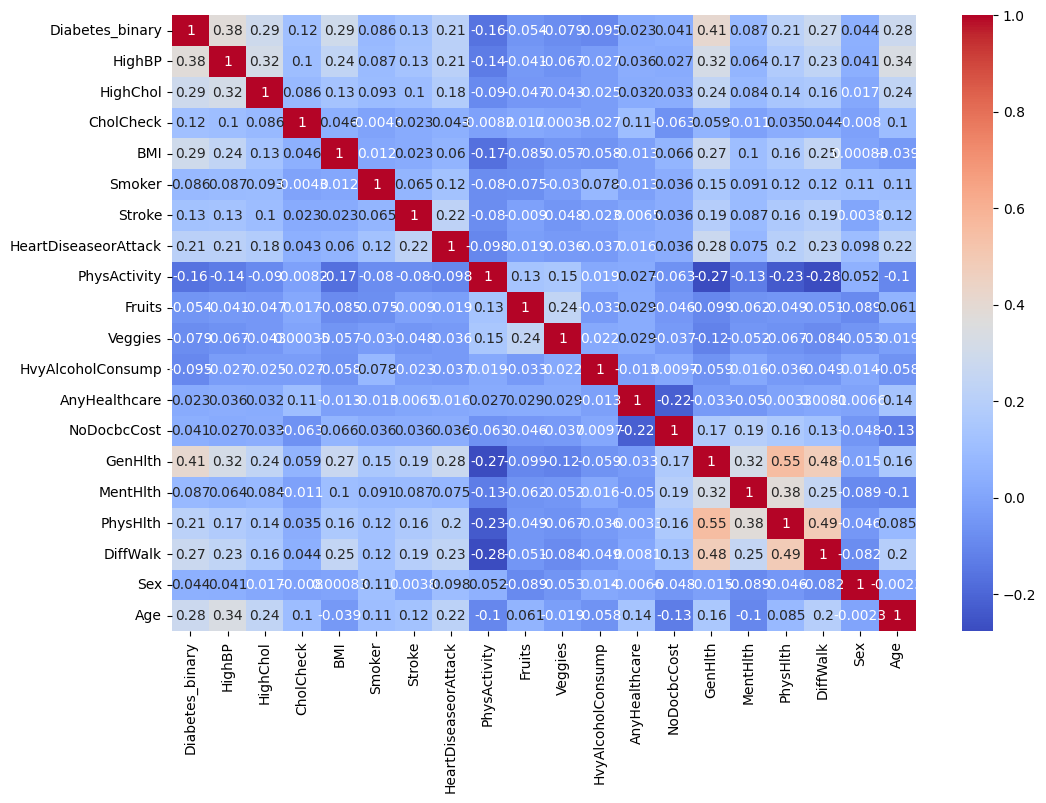

In [4]:
sns.countplot(x='Diabetes_binary', data=df)
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Feature Engineering
In this step, we clean the dataset by removing duplicates and preparing features for model training. Since most features are already numerical, minimal transformation is required.

In [5]:
# Remove duplicates
df = df.drop_duplicates()

# Define features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

## Model Selection and Training
We use Random Forest Classifier as it performs well on classification tasks and handles feature importance effectively.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model Evaluation
The model is evaluated using accuracy score, classification report, and confusion matrix.

Accuracy: 0.6947368421052632
              precision    recall  f1-score   support

         0.0       0.69      0.65      0.67      6180
         1.0       0.70      0.74      0.72      6740

    accuracy                           0.69     12920
   macro avg       0.69      0.69      0.69     12920
weighted avg       0.69      0.69      0.69     12920



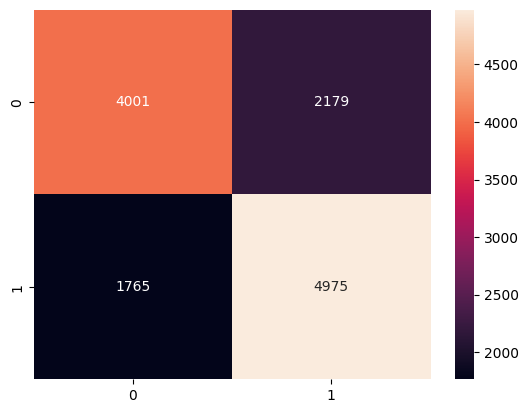

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

The model achieved an accuracy of approximately 69.47%. The confusion matrix shows that the model performs well in distinguishing between diabetic and non-diabetic cases.

## Feature Importance Analysis
This step identifies which features contribute most to the prediction.

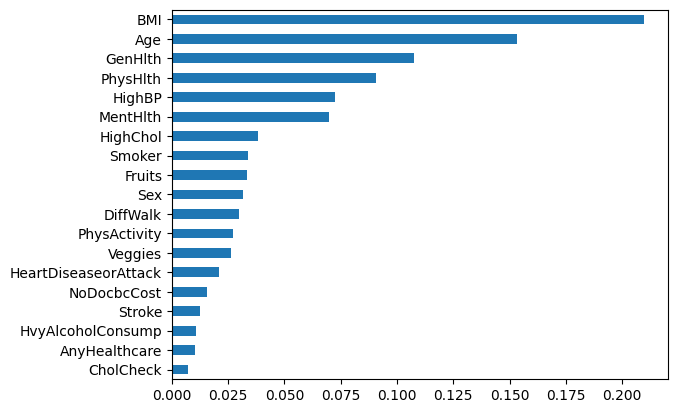

In [8]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values()

feat_imp.plot(kind='barh')
plt.show()

BMI, Age, HighBP, and HighChol are among the most important features influencing diabetes prediction.

## Result Interpretation

The machine learning model was successfully trained and evaluated on the dataset. The results indicate that health indicators such as BMI, age, blood pressure, and cholesterol levels play a significant role in predicting diabetes.

The model achieved good accuracy and can effectively classify individuals as diabetic or non-diabetic.

## Conclusion

The methodology defined in phase-1 was successfully implemented. The project meets its objective of predicting diabetes risk using machine learning techniques.

In [9]:
# Try another model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr.predict(X_test)))

Logistic Regression Accuracy: 0.7339783281733746
